In [2]:
import os

In [3]:
host = os.getenv('SQL_HOST', 'localhost')
port = os.getenv('SQL_PORT', '5432')
user = os.getenv('SQL_USER')
password = os.getenv('SQL_PASSWORD')
database = os.getenv('SQL_DB', 'sdb')

In [4]:
from sqlalchemy import inspect
from sqlalchemy import create_engine

In [5]:
connection_string = f"postgresql://{user}:{password}@{host}:{port}/{database}"
# print(connection_string)

In [6]:
engine = create_engine(connection_string)
inspector = inspect(engine)
print(inspector.get_table_names())

['spatial_ref_sys', 'nyc_census_blocks', 'geometrics', 'nyc_neighborhoods', 'nyc_subway_stations', 'nyc_homicides', 'nyc_streets']


In [7]:
continents = inspector.get_columns('nyc_neighborhoods')
for column in continents:
    print(column['name'], column['type'])

id INTEGER
geom NULL
boroname VARCHAR(43)
name VARCHAR(64)


C:\Users\VIKASH KUMAR\AppData\Local\Temp\ipykernel_24944\1833108416.py:1: SAWarning: Did not recognize type 'geometry' of column 'geom'
  continents = inspector.get_columns('nyc_neighborhoods')


Working with GeoPandas

In [8]:
import geopandas as gpd

In [9]:
sql = 'SELECT * FROM nyc_neighborhoods LIMIT 10;'

In [10]:
conn = engine.raw_connection()
gdf = gpd.read_postgis(sql, conn, geom_col="geom")
conn.close()


f:\Python\FastAPI01\myenv\Lib\site-packages\geopandas\io\sql.py:185: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(
f:\Python\FastAPI01\myenv\Lib\site-packages\geopandas\io\sql.py:467: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(spatial_ref_sys_sql, con)


In [11]:
gdf.head()

,id,geom,boroname,name
0,1,"MULTIPOLYGON (((582771.426 4495167.427, 584651...",Brooklyn,Bensonhurst
1,2,"MULTIPOLYGON (((585508.753 4509691.267, 586826...",Manhattan,East Village
2,3,"MULTIPOLYGON (((583263.278 4509242.626, 583276...",Manhattan,West Village
3,4,"MULTIPOLYGON (((597640.009 4520272.72, 597647....",The Bronx,Throggs Neck
4,5,"MULTIPOLYGON (((595285.205 4525938.798, 595348...",The Bronx,Wakefield-Williamsbridge


In [12]:
gdf.crs

<Projected CRS: EPSG:26918>
Name: NAD83 / UTM zone 18N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: North America - between 78°W and 72°W - onshore and offshore. Canada - Nunavut; Ontario; Quebec. United States (USA) - Connecticut; Delaware; Maryland; Massachusetts; New Hampshire; New Jersey; New York; North Carolina; Pennsylvania; Virginia; Vermont.
- bounds: (-78.0, 28.28, -72.0, 84.0)
Coordinate Operation:
- name: UTM zone 18N
- method: Transverse Mercator
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

Extracting executed tables as files

In [13]:
from pathlib import Path

In [14]:
out_dir = Path(r"F:\SQL\sql_output")
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

In [15]:
out_json = os.path.join(out_dir, 'nyc_neighborhoods1.json')
gdf.to_file(out_json, driver='GeoJSON')

In [16]:
out_json = os.path.join(out_dir, 'nyc_neighborhoods1.shp')
gdf.to_file(out_json)

In [17]:
gdf = gdf.set_index("name")

In [18]:
gdf["area"] = gdf.area
gdf["area"]

name
Bensonhurst                 5.828014e+06
East Village                1.632117e+06
West Village                1.044615e+06
Throggs Neck                8.274104e+06
Wakefield-Williamsbridge    6.925334e+06
Auburndale                  6.337966e+06
Battery Park                4.901918e+05
Carnegie Hill               3.865175e+05
Mariners Harbor             6.109654e+06
Rossville                   4.402976e+06
Name: area, dtype: float64

In [19]:
gdf["boundary"] = gdf.boundary
gdf["boundary"]

name
Bensonhurst                 MULTILINESTRING ((582771.426 4495167.427, 5846...
East Village                MULTILINESTRING ((585508.753 4509691.267, 5868...
West Village                MULTILINESTRING ((583263.278 4509242.626, 5832...
Throggs Neck                MULTILINESTRING ((597640.009 4520272.72, 59764...
Wakefield-Williamsbridge    MULTILINESTRING ((595285.205 4525938.798, 5953...
Auburndale                  MULTILINESTRING ((600973.009 4510338.857, 6010...
Battery Park                MULTILINESTRING ((583408.101 4508093.111, 5833...
Carnegie Hill               MULTILINESTRING ((588501.208 4515525.88, 58812...
Mariners Harbor             MULTILINESTRING ((570300.108 4497031.156, 5703...
Rossville                   MULTILINESTRING ((564664.957 4489358.427, 5647...
Name: boundary, dtype: geometry

In [20]:
gdf.head()

,id,geom,boroname,area,boundary
name,,,,,
Bensonhurst,1,"MULTIPOLYGON (((582771.426 4495167.427, 584651...",Brooklyn,5.828014e+06,"MULTILINESTRING ((582771.426 4495167.427, 5846..."
East Village,2,"MULTIPOLYGON (((585508.753 4509691.267, 586826...",Manhattan,1.632117e+06,"MULTILINESTRING ((585508.753 4509691.267, 5868..."
West Village,3,"MULTIPOLYGON (((583263.278 4509242.626, 583276...",Manhattan,1.044615e+06,"MULTILINESTRING ((583263.278 4509242.626, 5832..."
Throggs Neck,4,"MULTIPOLYGON (((597640.009 4520272.72, 597647....",The Bronx,8.274104e+06,"MULTILINESTRING ((597640.009 4520272.72, 59764..."
Wakefield-Williamsbridge,5,"MULTIPOLYGON (((595285.205 4525938.798, 595348...",The Bronx,6.925334e+06,"MULTILINESTRING ((595285.205 4525938.798, 5953..."


In [21]:
gdf["centroid"] = gdf.centroid
gdf["centroid"]

name
Bensonhurst                 POINT (584653.928 4495863.485)
East Village                POINT (585979.191 4508859.571)
West Village                POINT (583832.311 4509898.957)
Throggs Neck                POINT (599226.101 4519629.728)
Wakefield-Williamsbridge    POINT (596720.653 4527170.627)
Auburndale                  POINT (602204.283 4511825.554)
Battery Park                 POINT (583101.819 4507281.95)
Carnegie Hill               POINT (588104.215 4515281.878)
Mariners Harbor             POINT (571174.431 4497431.442)
Rossville                   POINT (566375.406 4489010.523)
Name: centroid, dtype: geometry

<Axes: >

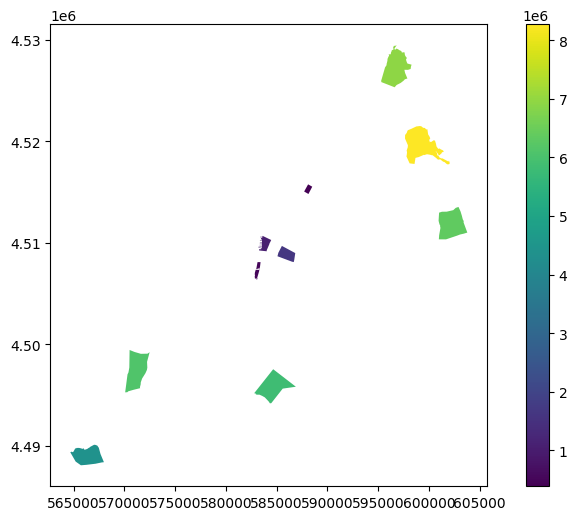

In [22]:
gdf.plot("area", legend=True, figsize=(10, 6))

<Axes: >

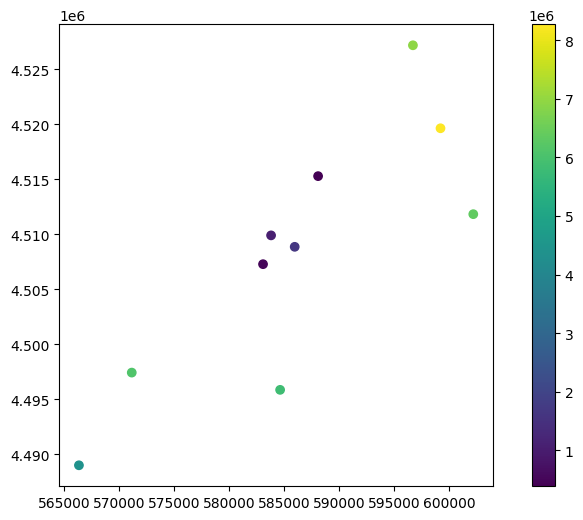

In [23]:
gdf = gdf.set_geometry("centroid")
gdf.plot("area", legend=True, figsize=(10, 6))

<Axes: >

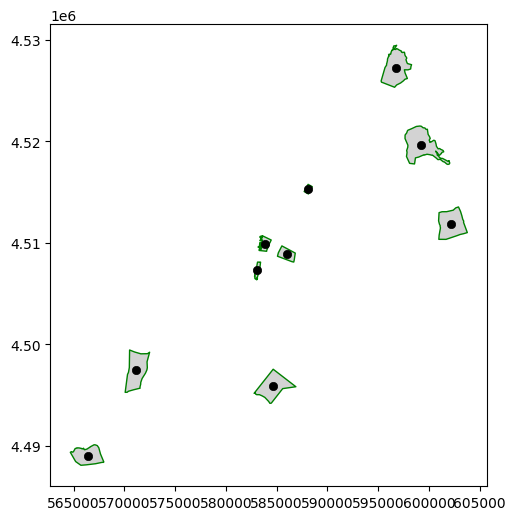

In [24]:
ax = gdf["geom"].plot(figsize=(10, 6), color="lightgray", edgecolor="green")
gdf["centroid"].plot(ax=ax, color="black", linewidth=0.5)

In [25]:
gdf = gdf.set_geometry("geom")

Reprojecting Data

In [26]:
sql = 'SELECT * FROM nyc_neighborhoods;'

In [27]:
conn = engine.raw_connection()
gdf = gpd.read_postgis(sql, conn, geom_col="geom")
conn.close()

f:\Python\FastAPI01\myenv\Lib\site-packages\geopandas\io\sql.py:185: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(
f:\Python\FastAPI01\myenv\Lib\site-packages\geopandas\io\sql.py:467: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(spatial_ref_sys_sql, con)


In [28]:
conn = engine.raw_connection()
gdf = gpd.read_postgis(sql, conn, geom_col='geom')
conn.close()


In [29]:
gdf.head()

,id,geom,boroname,name
0,1,"MULTIPOLYGON (((582771.426 4495167.427, 584651...",Brooklyn,Bensonhurst
1,2,"MULTIPOLYGON (((585508.753 4509691.267, 586826...",Manhattan,East Village
2,3,"MULTIPOLYGON (((583263.278 4509242.626, 583276...",Manhattan,West Village
3,4,"MULTIPOLYGON (((597640.009 4520272.72, 597647....",The Bronx,Throggs Neck
4,5,"MULTIPOLYGON (((595285.205 4525938.798, 595348...",The Bronx,Wakefield-Williamsbridge


<Axes: >

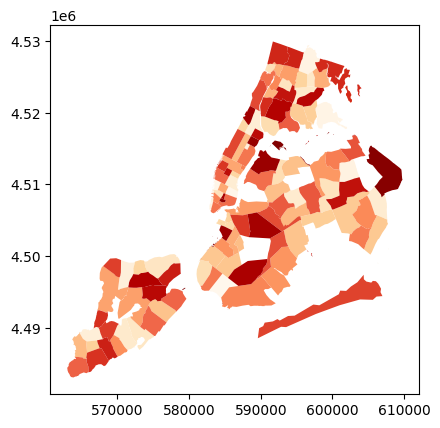

In [30]:
gdf.plot( cmap="OrRd", legend=True)

In [31]:
# Reproject to WGS 84 (EPSG:4326)
gdf_crs = gdf.to_crs(epsg=4326)
gdf_crs

,id,geom,boroname,name
0,1,"MULTIPOLYGON (((-74.02167 40.60318, -73.99913 ...",Brooklyn,Bensonhurst
1,2,"MULTIPOLYGON (((-73.98734 40.73372, -73.97184 ...",Manhattan,East Village
2,3,"MULTIPOLYGON (((-74.01399 40.72991, -74.01381 ...",Manhattan,West Village
3,4,"MULTIPOLYGON (((-73.84204 40.82767, -73.8419 4...",The Bronx,Throggs Neck
4,5,"MULTIPOLYGON (((-73.8691 40.87898, -73.86831 4...",The Bronx,Wakefield-Williamsbridge
...,...,...,...,...
124,125,"MULTIPOLYGON (((-74.00367 40.66747, -74.00256 ...",Brooklyn,Red Hook
125,126,"MULTIPOLYGON (((-73.75494 40.76612, -73.75483 ...",Queens,Douglastown-Little Neck
126,127,"MULTIPOLYGON (((-73.81296 40.79708, -73.81296 ...",Queens,Whitestone
127,128,"MULTIPOLYGON (((-73.89509 40.78149, -73.89419 ...",Queens,Steinway


In [45]:
geojson = gdf_crs.__geo_interface__ # Convert GeoDataFrame to GeoJSON format, beacuse normal json is not working with geemap
geojson  

{'type': 'FeatureCollection',
 'features': [{'id': '0',
   'type': 'Feature',
   'properties': {'id': 1, 'boroname': 'Brooklyn', 'name': 'Bensonhurst'},
   'geometry': {'type': 'MultiPolygon',
    'coordinates': [(((-74.02166685535772, 40.603177255343375),
       (-73.99913147363611, 40.624372593164594),
       (-73.99009780649752, 40.61893594779441),
       (-73.9729400064375, 40.60861003332049),
       (-73.98831003047552, 40.60705997223439),
       (-74.00178181818161, 40.59428181818518),
       (-74.00335111288342, 40.59411826596878),
       (-74.00489300358643, 40.595888584924175),
       (-74.00683464373093, 40.59748758269029),
       (-74.00921877856383, 40.59945098784679),
       (-74.01221793603153, 40.60078218425389),
       (-74.01544789453493, 40.601922474707386),
       (-74.01739945039984, 40.601941933610085),
       (-74.01865704049212, 40.6019544730017),
       (-74.01984746586552, 40.60245151206188),
       (-74.02009090942352, 40.603209091308386),
       (-74.02166685

In [33]:
import geemap

In [ ]:
m = geemap.Map(center=[40.7128, -74.0060], zoom=10, ee_initialize=False)
m

In [35]:
style = {
    "color": "#04FF009D",
    "fill_color": "#DFC310",
    "weight": 2,
    "fill" : True,
    "fillColor": "cyan",
    "fillOpacity": 0.5,
    "stroke": True

}

In [44]:
m.add_geojson(geojson, style=style, layer_name="NYC Neighborhoods")

In [46]:
m

Map(bottom=197257.0, center=[40.6426145676101, -73.8823242042143], controls=(WidgetControl(options=['position'…

adding another layer

In [47]:
sql2 = 'SELECT * FROM nyc_subway_stations;'

In [49]:
conn = engine.raw_connection()
gdf_subway = gpd.read_postgis(sql2, conn, geom_col='geom')
conn.close()

In [50]:
gdf_subway.head()

,id,geom,objectid,name,alt_name,cross_st,long_name,label,borough,nghbhd,routes,transfers,color,express,closed
0,376.0,POINT (583521.854 4507077.863),1.0,Cortlandt St,None,Church St,"Cortlandt St (R,W) Manhattan","Cortlandt St (R,W)",Manhattan,None,"R,W","R,W",YELLOW,None,None
1,2.0,POINT (583324.487 4506805.373),2.0,Rector St,None,None,Rector St (1) Manhattan,Rector St (1),Manhattan,None,1,1,RED,None,None
2,1.0,POINT (583304.182 4506069.654),3.0,South Ferry,None,None,South Ferry (1) Manhattan,South Ferry (1),Manhattan,None,1,1,RED,None,None
3,125.0,POINT (590250.106 4518558.02),4.0,138th St,Grand Concourse,Grand Concourse,"138th St / Grand Concourse (4,5) Bronx","138th St / Grand Concourse (4,5)",Bronx,None,"4,5","4,5",GREEN,None,None
4,126.0,POINT (590454.74 4519145.72),5.0,149th St,Grand Concourse,Grand Concourse,149th St / Grand Concourse (4) Bronx,149th St / Grand Concourse (4),Bronx,None,4,"2,4,5",GREEN,express,None


In [51]:
gdf_subway_crs = gdf_subway.to_crs(epsg="4326")

In [55]:
subway_geojson = gdf_subway_crs.__geo_interface__

In [56]:
m.add_geojson(subway_geojson, style=style, layer_name='nyc_subway_streets')

In [57]:
m

Map(bottom=394881.0, center=[40.62515819144965, -73.86245727539064], controls=(WidgetControl(options=['positio…